In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("supply_chain_data.csv")

print(df.shape)
df.head()

(100, 24)


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [3]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

In [4]:
# Remove duplicates
df = df.drop_duplicates()

# Fill missing values

for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

for col in df.select_dtypes(exclude='object'):
    df[col].fillna(df[col].median(), inplace=True)

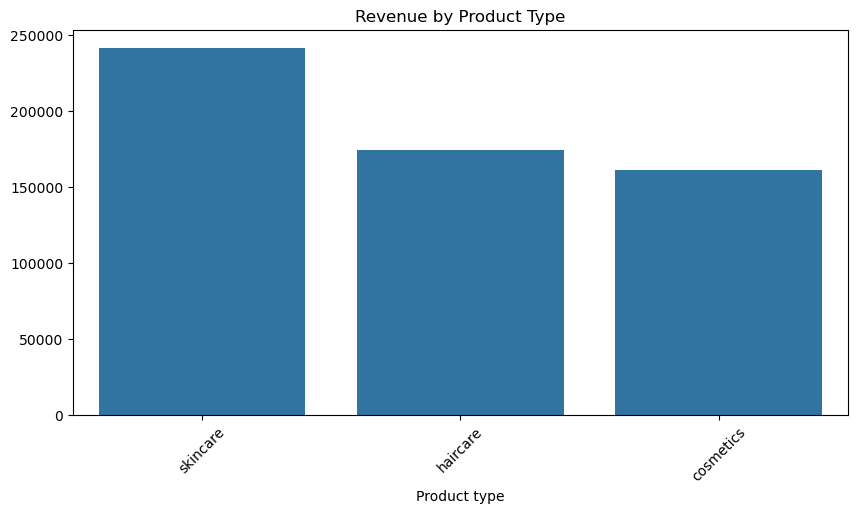

In [5]:
plt.figure(figsize=(10,5))

top_products = (
    df.groupby('Product type')['Revenue generated']
    .sum()
    .sort_values(ascending=False)
)

sns.barplot(
    x=top_products.index,
    y=top_products.values
)

plt.xticks(rotation=45)
plt.title("Revenue by Product Type")
plt.show()

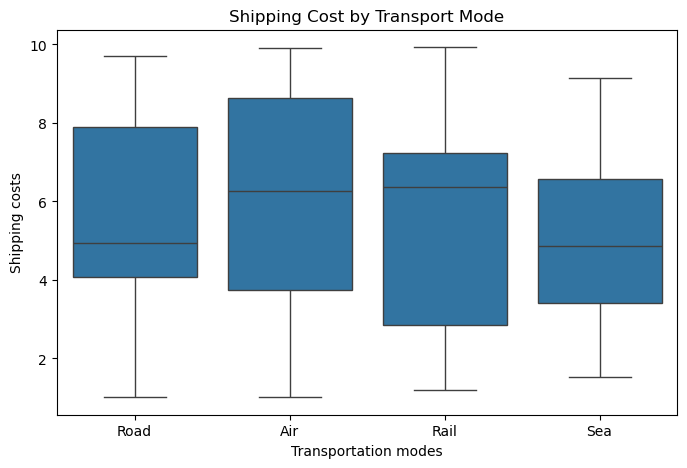

In [6]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Transportation modes',
    y='Shipping costs'
)

plt.title("Shipping Cost by Transport Mode")
plt.show()

In [7]:
supplier_perf = (
    df.groupby('Supplier name')
    .agg({
        'Lead time':'mean',
        'Defect rates':'mean',
        'Revenue generated':'sum'
    })
)

supplier_perf.sort_values(
    by='Defect rates',
    ascending=False
).head()

,Lead time,Defect rates,Revenue generated
Supplier name,,,
Supplier 5,18.055556,2.665408,110343.463656
Supplier 3,20.133333,2.465786,97795.979638
Supplier 2,18.545455,2.362750,125467.418605
Supplier 4,15.222222,2.337397,86468.961799
Supplier 1,14.777778,1.803630,157528.995039


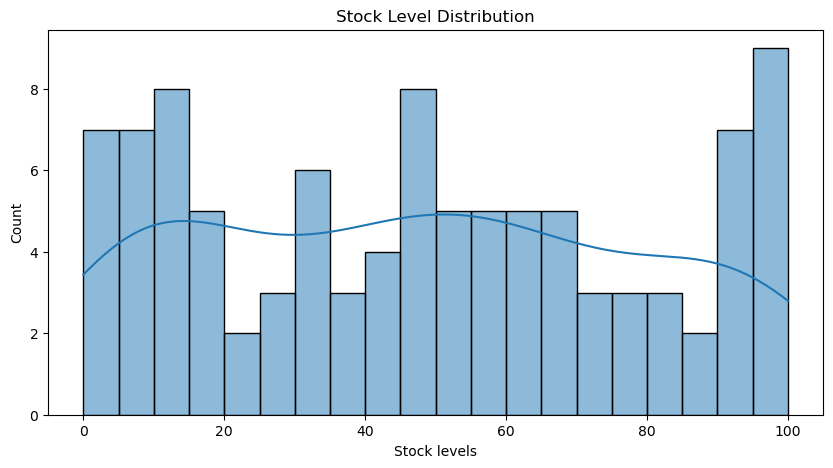

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Stock levels'],
    bins=20,
    kde=True
)

plt.title("Stock Level Distribution")
plt.show()

In [9]:
route_analysis = (
    df.groupby('Routes')
    .agg({
        'Lead time':'mean',
        'Shipping costs':'mean'
    })
)

route_analysis.sort_values(
    by='Lead time',
    ascending=False
).head(10)

,Lead time,Shipping costs
Routes,,
Route B,18.162162,5.551986
Route C,16.550000,5.903218
Route A,16.395349,5.379699


Supplier name
Supplier 5    2.665408
Supplier 3    2.465786
Supplier 2    2.362750
Supplier 4    2.337397
Supplier 1    1.803630
Name: Defect rates, dtype: float64


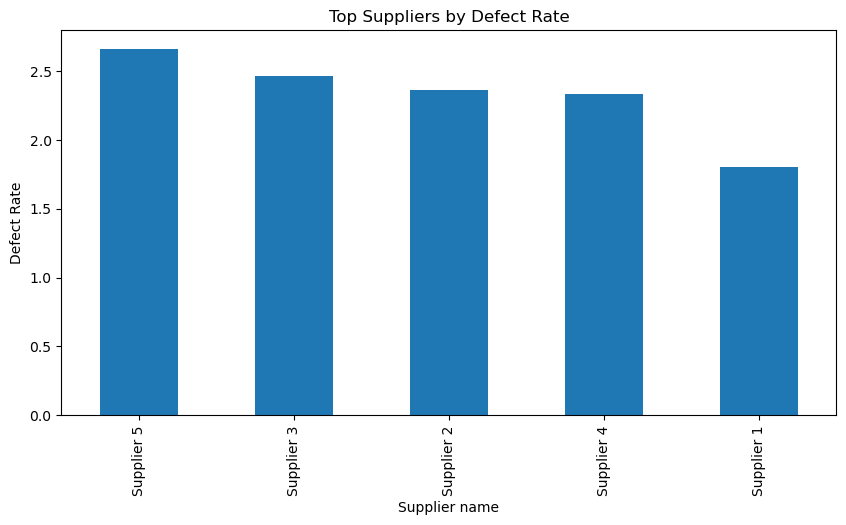

In [11]:
root_cause = (
    df.groupby('Supplier name')['Defect rates']
    .mean()
    .sort_values(ascending=False)
)

print(root_cause.head())

plt.figure(figsize=(10,5))

root_cause.head(10).plot(kind='bar')

plt.title("Top Suppliers by Defect Rate")
plt.ylabel("Defect Rate")
plt.show()

In [17]:
df['High_Risk'] = np.where(
    df['Defect rates'] > df['Defect rates'].median(),
    1,
    0
)

              precision    recall  f1-score   support

           0       0.22      0.25      0.24         8
           1       0.45      0.42      0.43        12

    accuracy                           0.35        20
   macro avg       0.34      0.33      0.34        20
weighted avg       0.36      0.35      0.35        20



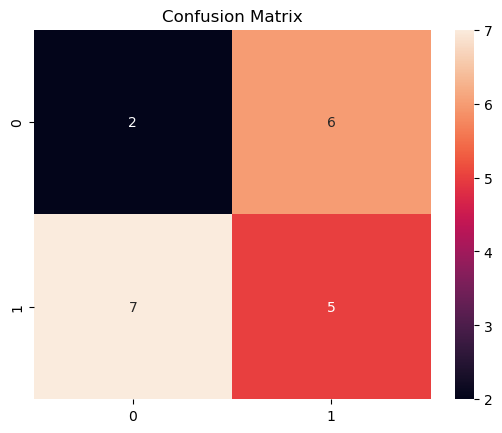

In [18]:
features = [
    'Price',
    'Availability',
    'Stock levels',
    'Lead time',
    'Shipping costs'
]

X = df[features]
y = df['High_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()

          Feature  Importance
3       Lead time    0.309322
0           Price    0.199159
2    Stock levels    0.176312
4  Shipping costs    0.165484
1    Availability    0.149723


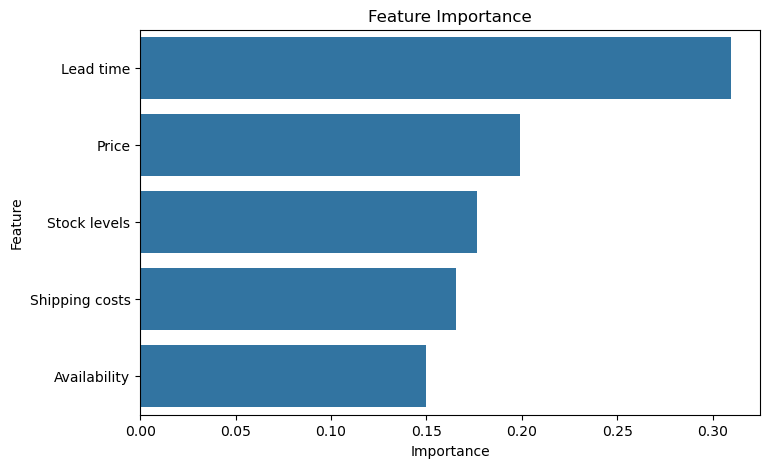

In [19]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")
plt.show()

In [23]:
top_product = (
    df.groupby('Product type')['Revenue generated']
      .sum()
      .sort_values(ascending=False)
)
print("Highest Revenue Product Category:")
print(f"{top_product.index[0]} : ${top_product.iloc[0]:,.2f}")


supplier_defect = (
    df.groupby('Supplier name')['Defect rates']
      .mean()
      .sort_values(ascending=False)
)
print("\nSupplier With Highest Defect Rate:")
print(f"{supplier_defect.index[0]} : {supplier_defect.iloc[0]:.2f}%")


route_delay = (
    df.groupby('Routes')['Lead time']
      .mean()
      .sort_values(ascending=False)
)
print("\nRoute With Maximum Lead Time:")
print(f"{route_delay.index[0]} : {route_delay.iloc[0]:.2f} days")


transport_cost = (
    df.groupby('Transportation modes')['Shipping costs']
      .mean()
      .sort_values(ascending=False)
)
print("\nTransportation Mode With Highest Cost:")
print(f"{transport_cost.index[0]} : ${transport_cost.iloc[0]:.2f}")


print("\nKey Factors Causing High-Risk Shipments:")

for i, row in importance.head(5).iterrows():
    print(
        f"{row['Feature']} "
        f"(Importance Score: {row['Importance']:.3f})"
    )




print("="*60)
print("SUPPLY CHAIN BUSINESS INSIGHTS REPORT")
print("="*60)

print(f"\n1. Highest Revenue Product Category:")
print(f"   {top_product.index[0]} "
      f"generated ${top_product.iloc[0]:,.2f}")

print(f"\n2. Supplier With Highest Defect Rate:")
print(f"   {supplier_defect.index[0]} "
      f"with {supplier_defect.iloc[0]:.2f}% defect rate")

print(f"\n3. Route Causing Maximum Delays:")
print(f"   {route_delay.index[0]} "
      f"with average lead time of {route_delay.iloc[0]:.2f} days")

print(f"\n4. Most Expensive Transportation Mode:")
print(f"   {transport_cost.index[0]} "
      f"with average shipping cost of ${transport_cost.iloc[0]:.2f}")

print("\n5. Top Drivers of High-Risk Shipments:")

for idx, row in importance.head(5).iterrows():
    print(
        f"   - {row['Feature']} "
        f"(Score: {row['Importance']:.3f})"
    )

print("\nRecommendations:")
print("• Optimize high-delay routes.")
print("• Monitor suppliers with high defect rates.")
print("• Maintain inventory for high-revenue products.")
print("• Review costly transportation modes.")
print("• Focus on ML-identified risk factors to reduce disruptions.")

Highest Revenue Product Category:
skincare : $241,628.16

Supplier With Highest Defect Rate:
Supplier 5 : 2.67%

Route With Maximum Lead Time:
Route B : 18.16 days

Transportation Mode With Highest Cost:
Air : $6.02

Key Factors Causing High-Risk Shipments:
Lead time (Importance Score: 0.309)
Price (Importance Score: 0.199)
Stock levels (Importance Score: 0.176)
Shipping costs (Importance Score: 0.165)
Availability (Importance Score: 0.150)
SUPPLY CHAIN BUSINESS INSIGHTS REPORT

1. Highest Revenue Product Category:
   skincare generated $241,628.16

2. Supplier With Highest Defect Rate:
   Supplier 5 with 2.67% defect rate

3. Route Causing Maximum Delays:
   Route B with average lead time of 18.16 days

4. Most Expensive Transportation Mode:
   Air with average shipping cost of $6.02

5. Top Drivers of High-Risk Shipments:
   - Lead time (Score: 0.309)
   - Price (Score: 0.199)
   - Stock levels (Score: 0.176)
   - Shipping costs (Score: 0.165)
   - Availability (Score: 0.150)

Recomm